# XL Inversions (delly short reads)
Here, we visualize the inversions that were identified for the `xl` treatment across the range of depths.

In [14]:
library(dplyr)
library(ggplot2)
library(ggpubr)
library(tidyr)
.size <- "xl"

These are the setup functions that process that data. We need to reformat the `.bedpe` files as long-form tables, and filter out missing (`./.`) and homozygous ref (`0/0`) genotypes.

In [15]:
read_data <- function(size_treatment, depth){
    .depth <- paste("depth", depth, sep = "_")
    samplesfile <- paste("../simulated_data/visor/called_sv/delly", size_treatment, .depth, "inversions.bedpe", sep = "/")

    sample_inversions <- read.table(samplesfile, header = T)[,-4] %>%
        pivot_longer(cols = c(-1,-2,-3), values_to = "genotype", names_to = "sample") %>%
        filter(genotype != "./.", genotype != "0/0") %>%
        select(-genotype)

    sample_inversions$depth <- depth
    sample_inversions$sample <- as.integer(gsub("sample_", "", sample_inversions$sample))
    return(sample_inversions)
}

read_all_data <- function(size_treatment){
    depth <- 0.5
    .data <- read_data(size_treatment, depth)    
    for(i in c(2,5,10,20)){
        .data <- rbind(.data, read_data(.size, i))    
    }
    return(.data)
}

In [16]:
samplesSV <- read_all_data(.size)
head(samplesSV)

contig,position_start,position_end,sample,depth
<chr>,<int>,<int>,<int>,<dbl>
2L,961595,21551119,4,0.5
2L,961595,21551119,7,0.5
2R,6686006,24798524,4,0.5
2R,6686006,24798524,6,0.5
2R,6686006,24798524,7,0.5
2R,6686006,24798524,10,0.5


Read in the sample and pool simulation inventory

In [17]:
performance <- read.table("../assess_sv_leviathan/visor/inversion.assessment", header = T)
performance <- performance[performance$size == .size,]
performance$assessment <- ifelse(performance$simulated, "false negative", "true negative")
head(performance)

,contig,inversion,id,depth,sample,size,simulated,zygosity,position_start,position_end,assessment
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>
2421,2L,1,1,0.5,1,xl,TRUE,homozygous,961650,21551190,false negative
2422,2L,1,1,2.0,1,xl,TRUE,homozygous,961650,21551190,false negative
2423,2L,1,1,5.0,1,xl,TRUE,homozygous,961650,21551190,false negative
2424,2L,1,1,10.0,1,xl,TRUE,homozygous,961650,21551190,false negative
2425,2L,1,1,20.0,1,xl,TRUE,homozygous,961650,21551190,false negative
2426,2L,1,1,0.5,2,xl,TRUE,homozygous,961650,21551190,false negative


### Assess the performance of identified inversions
We'll create a helper function that checks if an identified breakpoint is within 50bp of a known (simulated breakpoint).

In [18]:
near_breakpoint <- function(x, y, tolerance = 75){
    # x is the simulated/known breakpoints
    # y is the breakpoint we want to compare
    # check if y is within tolerance of x
    return(
        (y >= x - tolerance) & (y <= x + tolerance)
    )
}

In [19]:
false_positives <- samplesSV[0,]

for(i in 1:nrow(samplesSV)){
    .row <- samplesSV[i,]
    query <- which(
        performance$sample == .row$sample &
        performance$depth == .row$depth &
        performance$contig == .row$contig &
        near_breakpoint(performance$position_start, .row$position_start) &
        near_breakpoint(performance$position_end, .row$position_end)
    )
    if(length(query) > 0 && performance$simulated[query]){
        performance$assessment[query] <- "true positive"
    } else {
        performance$assessment[query] <- "false positive"
        false_positives <- rbind(false_positives, .row)
    }
}
head(performance)

,contig,inversion,id,depth,sample,size,simulated,zygosity,position_start,position_end,assessment
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>
2421,2L,1,1,0.5,1,xl,TRUE,homozygous,961650,21551190,false negative
2422,2L,1,1,2.0,1,xl,TRUE,homozygous,961650,21551190,false negative
2423,2L,1,1,5.0,1,xl,TRUE,homozygous,961650,21551190,true positive
2424,2L,1,1,10.0,1,xl,TRUE,homozygous,961650,21551190,true positive
2425,2L,1,1,20.0,1,xl,TRUE,homozygous,961650,21551190,true positive
2426,2L,1,1,0.5,2,xl,TRUE,homozygous,961650,21551190,false negative


Where there false positives?

In [20]:
head(false_positives)
if (nrow(false_positives) > 0) {
    false_positives$size <- .size
    false_positives$method <- "delly"
    write.table(false_positives, file = paste0("false_positives.", .size), row.names = F, quote = F)
}

contig,position_start,position_end,sample,depth
<chr>,<int>,<int>,<int>,<dbl>


This is extra formatting we need to do to get it to plot correctly

In [21]:
truth <- filter(performance, simulated) %>%
    select(contig, inversion, position_start, position_end) |> unique() %>%
    mutate(assessment = "true positive", sample = 0, depth = 20)

head(truth)

,contig,inversion,position_start,position_end,assessment,sample,depth
,<chr>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>
1,2L,1,961650,21551190,true positive,0,20
56,2R,1,6686007,24798525,true positive,0,20
111,3L,1,5332918,22935558,true positive,0,20
131,3R,1,5316416,31441385,true positive,0,20


### Single-Sample Detection
Let's first visualize what detection looked like across the genome. Here, we facet across contigs and show all the depths at once. Since the small inversions are indeed quite small, for visualization purposes, we'll make each of them 100 kb bigger.

In [22]:
plot_inversions <- function(data, fp, groundtruth, size_treatment){
    options(warn = -1, repr.plot.width = 19, repr.plot.height = 10)
    if (nrow(fp) > 0) {
        fp$assessment <- "false positive"
        fp$position_end <- fp$position_end + 100000
        fp$inversion <- 1
        .data <- rbind(
            select(data, contig, inversion, position_start, position_end, depth, assessment, sample),
            select(fp, contig, inversion, position_start, position_end, depth, assessment, sample)
        )
    } else {
        .data <- select(data, contig, inversion, position_start, position_end, depth, assessment, sample)
    }

    .tbl <- filter(.data, assessment == "true positive")

    rbind(.tbl, groundtruth) %>%
    ggplot(
        aes(
            x = sample,
            ymin = position_start,
            ymax = position_end+100000,
            color = as.factor(depth),
        )
    ) +
        geom_linerange(position = position_dodge(0.7), linewidth = 1.5) +
        coord_flip() +
        scale_color_brewer(name = "sequencing depth", palette = "Set2") +
        scale_x_continuous(breaks = 0:10,limits = c(0, 10)) +
        scale_y_continuous(labels = scales::comma) +
        theme_light() +
        theme(
            panel.grid.major.y = element_blank(),
            legend.position = "top",
            panel.grid.minor.y = element_line(color = "gray80", size = 0.5)
        ) +
        labs(
            title = "Simulated and Called Inversions Across the Genome",
            subtitle = paste0("Size: ", size_treatment),
            y = "genomic position (bp)",
            caption = "sample 0 = groundtruth | sample 11 = pooled"
        ) + 
        facet_grid(cols = vars(contig))
}

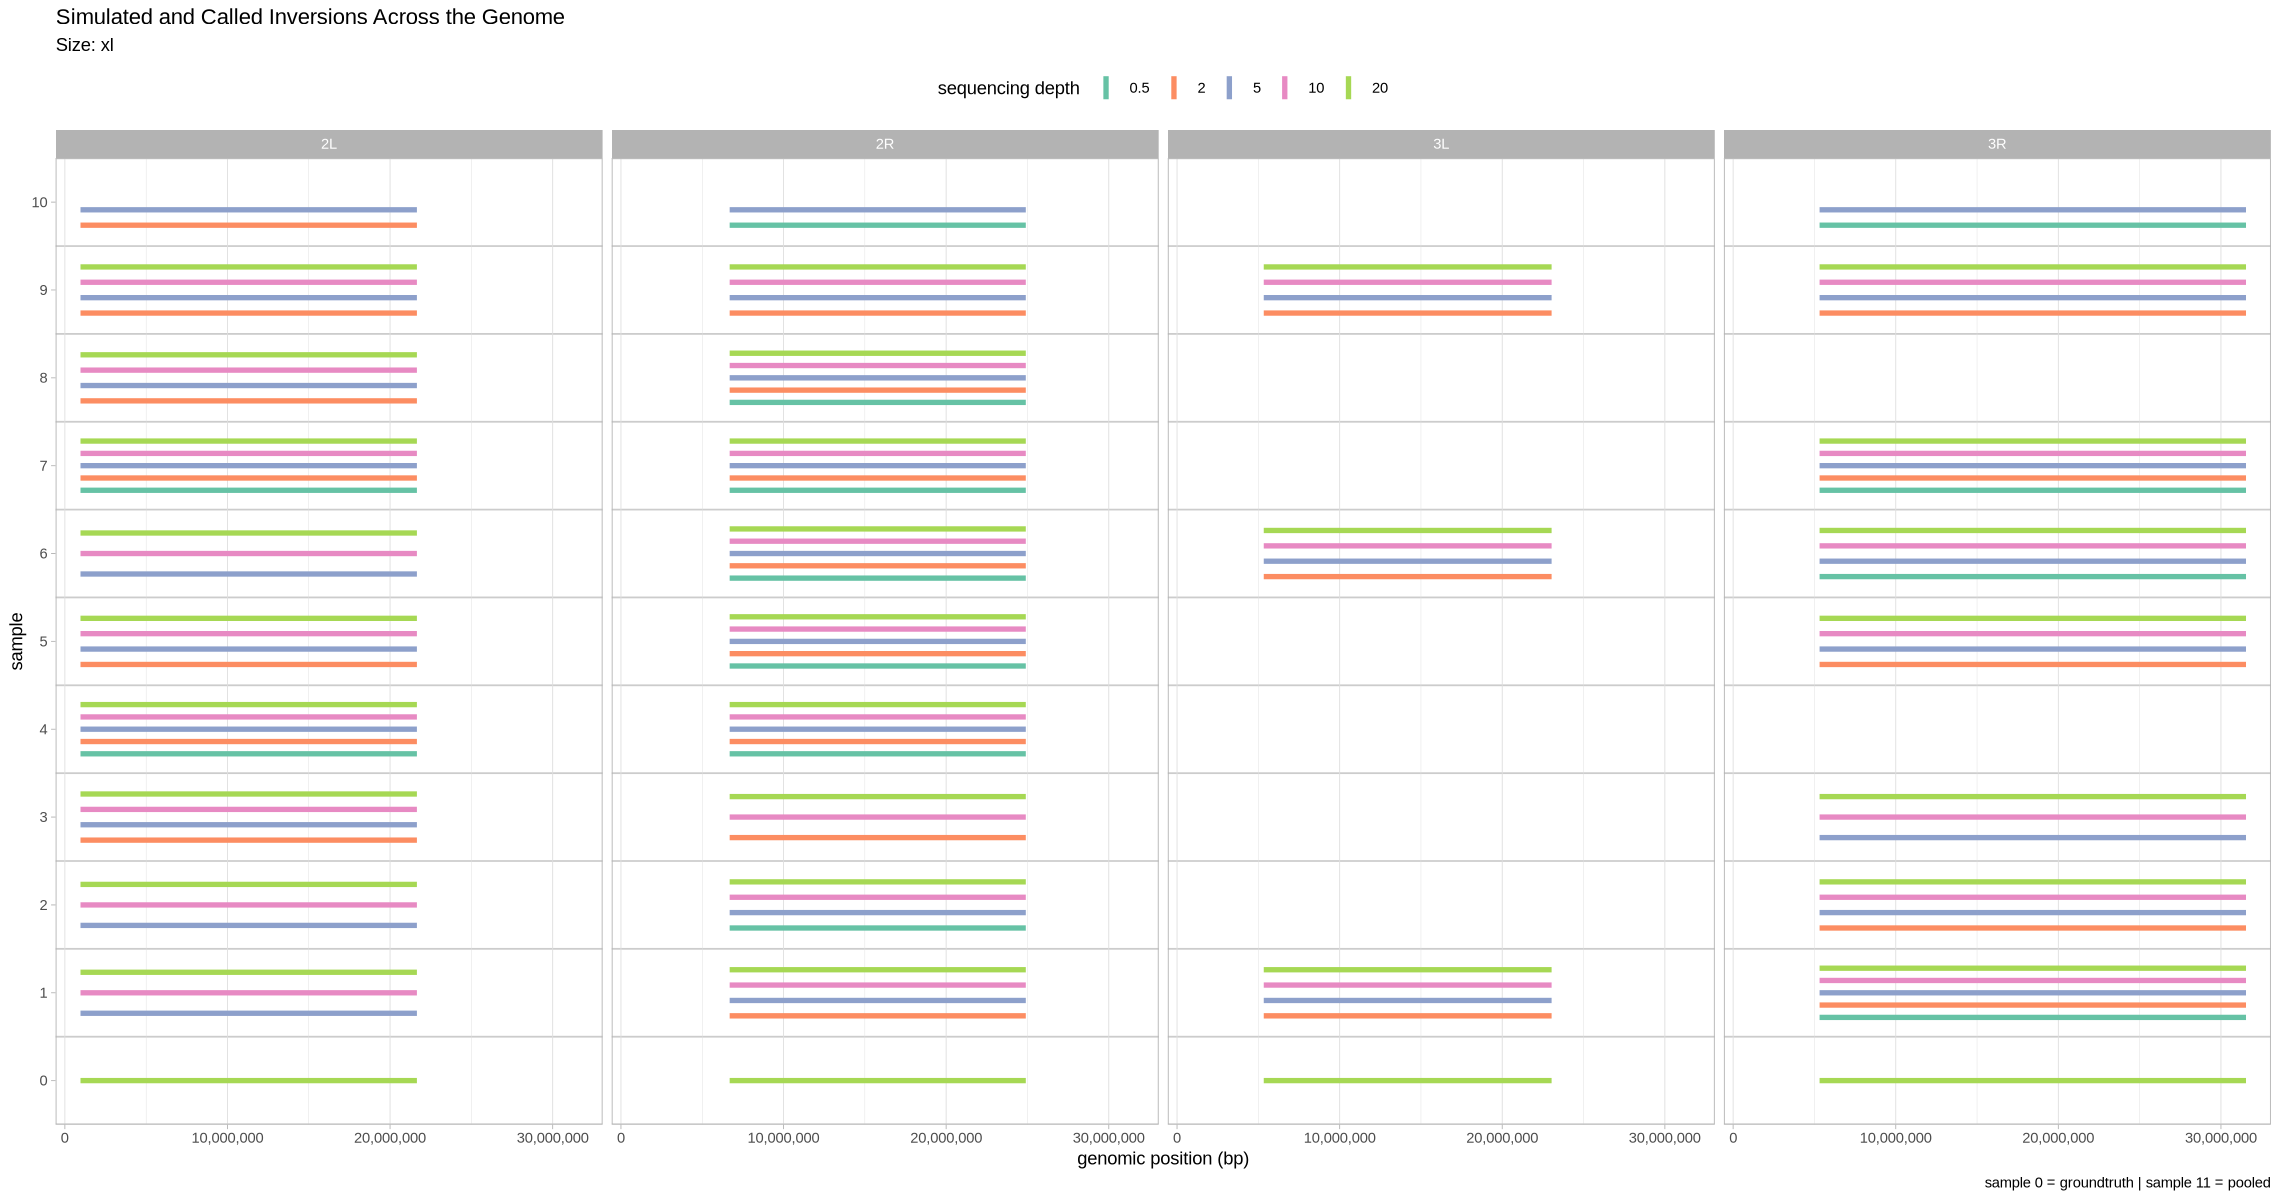

In [23]:
plot_inversions(performance, false_positives, truth, .size)

What does this look like as a heatmap of true/false positive/negative?

In [24]:
plot_samples_scattermatrix <- function(data, size_treatment){
    options(warn = -1, repr.plot.width = 5, repr.plot.height = 15)
    .data <- data[data$sample != 11,]
    axis_ticks <- factor(paste0("sample_", sprintf("%02d", 1:10)))
    ggplot(.data, aes(y = sample, x = inversion, color = assessment, fill = assessment, shape = zygosity)) +
        geom_point(size=6) +
        theme_light() +
        labs(title = "By-Sample Inversion Detection", subtitle = paste(size_treatment, "inversions detected in individual samples, as a function of zygotic state.")) +
        scale_color_manual(name = "Assessment", values = c("false negative" = "grey75", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_fill_manual(name = "Assessment", values = c("false negative" = "white", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_shape_manual(name = "Zygosity", values = c("homozygous" = 21, "heterozygous" = 22)) +
        scale_x_discrete(name = "Inversion") +
        scale_y_discrete(limits = axis_ticks, breaks = axis_ticks) +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_grid(cols = vars(contig), rows = vars(depth))
}

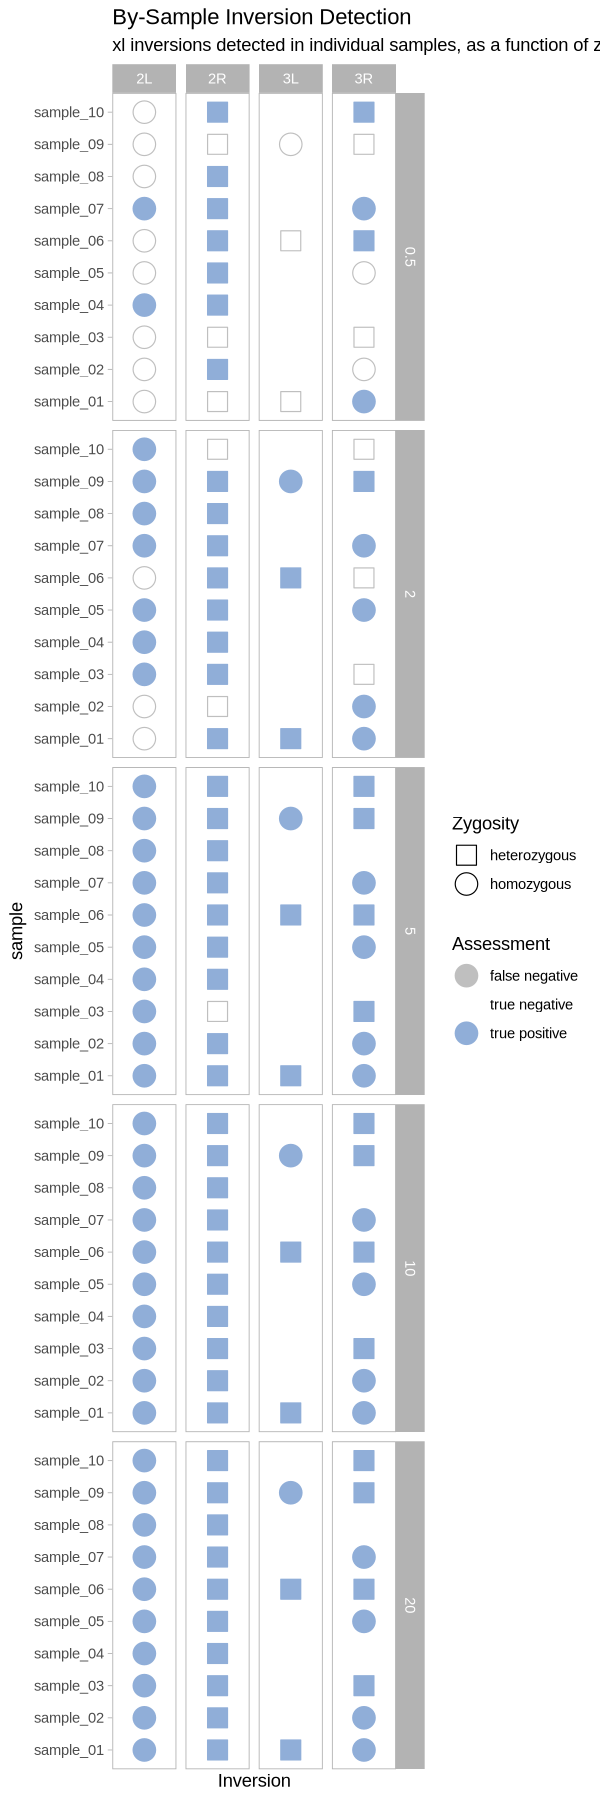

In [25]:
plot_samples_scattermatrix(performance, .size)

In [26]:
write.csv(performance, file = paste0(.size, ".sv.assessment"), quote = F, row.names = F)